In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

svm_raw = SVC()
svm_raw.fit(X_train, y_train)

pred_raw = svm_raw.predict(X_test)
print("Accuracy (no scaling):", accuracy_score(y_test, pred_raw))

Accuracy (no scaling): 0.9473684210526315


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_scaled = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])

svm_scaled.fit(X_train, y_train)

pred_scaled = svm_scaled.predict(X_test)
print("Accuracy (with scaling):", accuracy_score(y_test, pred_scaled))

Accuracy (with scaling): 0.9824561403508771


In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)

In [5]:
svm_raw_2d = SVC()
svm_raw_2d.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


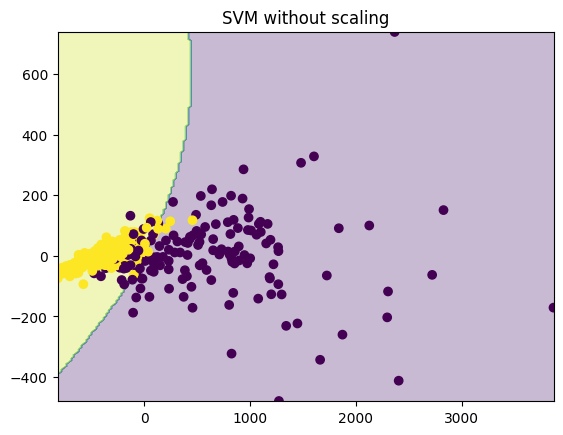

In [6]:
import numpy as np


def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()


plot_boundary(svm_raw_2d, X_train, y_train, "SVM without scaling")

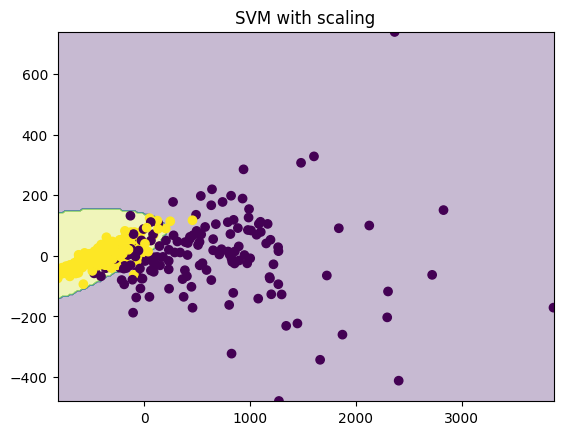

In [7]:
svm_scaled_2d = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])

svm_scaled_2d.fit(X_train, y_train)
plot_boundary(svm_scaled_2d, X_train, y_train, "SVM with scaling")